In [1]:
# ============================================================
# Figure 3D (last 3 panels): portable cache / plot-only version
#
# Default behavior:
#   - PLOT_ONLY = True
#   - load Figure3_D_last3_plot_inputs.npz only
#   - DO NOT touch original raw-data paths
#
# If you intentionally want to rebuild the cache on the lab machine,
# set PLOT_ONLY = False and rerun this cell.
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

PLOT_ONLY = True
CACHE_DIR = os.environ.get("FIGURE3_CACHE_DIR", os.getcwd())
CACHE_FILE = os.path.join(CACHE_DIR, "Figure3_D_last3_plot_inputs.npz")

print("Current working directory:", os.getcwd())
print("Cache directory:", CACHE_DIR)
print("Cache file:", CACHE_FILE)

if PLOT_ONLY:
    if not os.path.isfile(CACHE_FILE):
        raise FileNotFoundError(
            "Figure 3D plot-only mode: cache file not found.\n"
            f"Expected cache: {CACHE_FILE}\n"
            "No original raw-data files were opened.\n"
            "Create Figure3_D_last3_plot_inputs.npz once on the lab machine, "
            "or move it into the current cache directory, or set FIGURE3_CACHE_DIR."
        )

    with np.load(CACHE_FILE, allow_pickle=False) as cached:
        min_vals = cached["min_vals"]
        max_vals = cached["max_vals"]

        ripple_grid = cached["ripple_grid"]
        ripple_vmin = float(cached["ripple_vmin"])
        ripple_vmax = float(cached["ripple_vmax"])

        ied_grid = cached["ied_grid"]
        ied_vmin = float(cached["ied_vmin"])
        ied_vmax = float(cached["ied_vmax"])

        neither_grid = cached["neither_grid"]
        neither_vmin = float(cached["neither_vmin"])
        neither_vmax = float(cached["neither_vmax"])

    print(f"Loaded plot cache: {CACHE_FILE}")
    print("Plotting only — no UMAP or recomputation is being run.")

else:
    import glob
    import collections
    import h5py
    from scipy.io import loadmat
    import umap.umap_ as umap

    def load_rdata_field(f, field):
        """Load a field like 'ripples' or 'Rspikes' from q/Rdata robustly."""
        path = f['q']['Rdata'][field]
        data = np.array(path)

        results = []
        if data.dtype == object:
            for ref in data.flatten():
                if isinstance(ref, h5py.Reference):
                    results.append(np.array(f[ref]))
        else:
            results.append(data)
        return results

    def sample_indices_only(all_traces, n_samples=1000, seed=42):
        rng = np.random.default_rng(seed)
        n_total = all_traces.shape[0]
        if n_total < n_samples:
            raise ValueError(f"Not enough traces: have {n_total}, need {n_samples}.")
        idx = rng.choice(n_total, size=n_samples, replace=False)
        return idx

    def build_fraction_grid(embedding, combined_idx_1000, combined_idx_4000, positive_idx_5000):
        subset_idx = np.concatenate([combined_idx_1000, combined_idx_4000])
        subset_embed = embedding[subset_idx]
        positive_mask = np.isin(np.arange(len(subset_idx)), positive_idx_5000)

        min_vals = subset_embed.min(axis=0)
        max_vals = subset_embed.max(axis=0)
        x_bins = np.linspace(min_vals[0], max_vals[0], 20)
        y_bins = np.linspace(min_vals[1], max_vals[1], 20)

        grid_fraction = np.full((len(x_bins)-1, len(y_bins)-1), np.nan)

        for i in range(len(x_bins)-1):
            for j in range(len(y_bins)-1):
                in_bin = (
                    (subset_embed[:, 0] >= x_bins[i]) & (subset_embed[:, 0] < x_bins[i+1]) &
                    (subset_embed[:, 1] >= y_bins[j]) & (subset_embed[:, 1] < y_bins[j+1])
                )
                if np.sum(in_bin) > 0:
                    grid_fraction[i, j] = np.sum(positive_mask[in_bin]) / np.sum(in_bin) * 100

        positive_vals = grid_fraction[~np.isnan(grid_fraction)]
        vmin = float(np.nanmin(positive_vals))
        vmax = float(np.nanmax(positive_vals))
        return grid_fraction, min_vals, max_vals, vmin, vmax

    # -------------------------
    # Original heavy workflow
    # -------------------------
    pathname = '/scratch/dazhang/MATLAB/'
    preprocessed_path = '/data/an/preprocessed/'
    transformed_path = '/data/an/transformed/RR_h_referential_wSPKS/'

    pt_ch_mapping = {'EC130_200': [1, 13], 'EC133_200': [282, 291, 292, 293], 'EC135_200': [303], 'EC137_200': [257, 258, 259, 269], 'EC143_200': [339], 'EC157_200': [321, 332, 333, 334], 'EC162_200': [85, 86], 'EC175_200': [301, 302], 'EC183_200': [290], 'EC186_200': [299, 300, 301], 'EC187_200': [309, 310], 'EC191_200': [2, 3, 4], 'EC196_200': [300, 301, 303], 'EC219_200': [399, 400, 402, 403], 'EC220_200': [53, 54, 76, 77], 'EC221_200': [376, 377], 'EC222_200': [267, 268, 269, 270]}

    all_traces = np.empty((0, 513))
    all_specs_for_trace_pass = np.empty((0, 60))

    for patient, channal_list in pt_ch_mapping.items():
        patient_short = patient[:-4]
        transformed_patient_path = os.path.join(transformed_path, patient_short, 'AN')
        raw_patient_root = os.path.join(preprocessed_path, patient_short)
        mat_feature_path = os.path.join(pathname, patient)

        # block names from first channel
        first_ch = channal_list[0]
        rdata_file = os.path.join(transformed_patient_path, f'{patient_short}_AN_ch{first_ch}_wSPKS.mat')
        with h5py.File(rdata_file, 'r') as f:
            blocks_ref = np.asarray(f['q']['blocks'])
            if blocks_ref.ndim == 2 and blocks_ref.shape[0] == 1:
                blocks_ref = blocks_ref[0]
            else:
                blocks_ref = blocks_ref.flatten()
            block_names = []
            for ref in blocks_ref:
                codes = np.asarray(f[ref]).flatten()
                block_names.append(''.join(chr(int(c)) for c in codes))

        for each_channel in channal_list:
            feature_files = []
            for filename in glob.glob(os.path.join(mat_feature_path, '*.mat')):
                if ('ls_ripple' not in filename) or ('binsize_1_' in filename) or ('-empty' in filename):
                    continue
                if f'Channel_{each_channel}_' in filename:
                    feature_files.append(filename)
            feature_files = sorted(feature_files)

            rdata_file = os.path.join(transformed_patient_path, f'{patient_short}_AN_ch{each_channel}_wSPKS.mat')
            with h5py.File(rdata_file, 'r') as f:
                ripple_blocks = load_rdata_field(f, 'ripples')
                spike_blocks = load_rdata_field(f, 'Rspikes_THISchannel')

            file_counter = 0
            for block_idx, (ripples, spikes, block_name) in enumerate(zip(ripple_blocks, spike_blocks, block_names), start=1):
                ripples = np.atleast_2d(ripples)
                spikes = np.atleast_1d(spikes)
                if ripples.shape == (1, 2) and spikes.shape == (2,):
                    continue
                if file_counter >= len(feature_files):
                    break

                feature_file = feature_files[file_counter]
                ls_specs = loadmat(feature_file)['ls_ripple']
                raw_file = os.path.join(raw_patient_root, f'{patient_short}_{block_name}', 'MAT files', f'{patient_short}_{block_name}_notched.mat')
                a = loadmat(raw_file)
                raw_lfp = np.hstack([a['d'][:, each_channel]])
                spike_times_list = np.asarray(ripples.T).astype(int).tolist()

                cur_trace = np.empty((0, 513))
                for each_idx in range(len(spike_times_list)):
                    st = spike_times_list[each_idx]
                    if st - 256 >= 0 and st + 257 <= raw_lfp.shape[0]:
                        cur_trace = np.concatenate([cur_trace, raw_lfp[st-256:st+257].reshape(1, 513)], axis=0)
                if len(cur_trace) == len(ls_specs):
                    all_traces = np.concatenate([all_traces, cur_trace], axis=0)
                    all_specs_for_trace_pass = np.concatenate([all_specs_for_trace_pass, ls_specs], axis=0)
                file_counter += 1

    print('all_traces:', all_traces.shape)

    combined_idx_1000 = sample_indices_only(all_traces, n_samples=1000, seed=123)
    combined_idx_4000 = np.concatenate([
        sample_indices_only(all_traces, n_samples=1000, seed=456),
        sample_indices_only(all_traces, n_samples=1000, seed=789),
        sample_indices_only(all_traces, n_samples=1000, seed=101112),
        sample_indices_only(all_traces, n_samples=1000, seed=131415),
    ], axis=0)

    print('combined_idx_1000:', combined_idx_1000.shape)
    print('combined_idx_4000:', combined_idx_4000.shape)

    all_specs_label = []
    all_specs = np.empty((0, 60))
    for patient, channal_list in pt_ch_mapping.items():
        path = pathname + patient + '/'
        ls_specs = np.empty((0, 60))
        for cur_channel in channal_list:
            cur_channel = str(cur_channel)
            for filename in glob.glob(os.path.join(path, '*.mat')):
                if ('ls_ripple' not in filename) or ('binsize_1_' in filename):
                    continue
                if 'Channel_' + str(cur_channel) + '_' in filename and ('-empty' not in filename):
                    specs = loadmat(filename)['ls_ripple']
                    ls_specs = np.concatenate([ls_specs, specs], axis=0)
        all_specs_label = np.concatenate([all_specs_label, [patient] * len(ls_specs)])
        all_specs = np.concatenate([all_specs, ls_specs], axis=0)

    print('all_specs:', all_specs.shape)
    all_vectors = np.asarray(all_specs)
    embedding = umap.UMAP(
        n_components=2,
        min_dist=0.2,
        metric='euclidean',
        n_neighbors=15,
        random_state=42,
        n_epochs=100,
        verbose=True
    ).fit_transform(all_vectors)
    print('embedding:', embedding.shape)

    label_Da = loadmat('labels_final_Da_50.mat')['labels_all']
    label_Jon = loadmat('labels_final_Jon_50.mat')['labels_all']
    labels_Jon = [x.item() for x in label_Jon.flatten()]
    labels_Da = [x.item() for x in label_Da.flatten()]
    both_ripple = (np.array(labels_Jon) == 'Ripple') & (np.array(labels_Da) == 'Ripple')
    both_ied = (np.array(labels_Jon) == 'IED') & (np.array(labels_Da) == 'IED')
    both_neither = (np.array(labels_Jon) == 'Neither') & (np.array(labels_Da) == 'Neither')
    ripple_idx_both_50 = np.where(both_ripple)[0]
    ied_idx_both_50 = np.where(both_ied)[0]
    neither_idx_both_50 = np.where(both_neither)[0]

    ripple_grid, min_vals, max_vals, ripple_vmin, ripple_vmax = build_fraction_grid(
        embedding, combined_idx_1000, combined_idx_4000, ripple_idx_both_50
    )
    ied_grid, _, _, ied_vmin, ied_vmax = build_fraction_grid(
        embedding, combined_idx_1000, combined_idx_4000, ied_idx_both_50
    )
    neither_grid, _, _, neither_vmin, neither_vmax = build_fraction_grid(
        embedding, combined_idx_1000, combined_idx_4000, neither_idx_both_50
    )

    os.makedirs(CACHE_DIR, exist_ok=True)
    tmp_file = CACHE_FILE + '.tmp.npz'
    if os.path.exists(tmp_file):
        os.remove(tmp_file)

    np.savez(
        tmp_file,
        min_vals=min_vals,
        max_vals=max_vals,
        ripple_grid=ripple_grid,
        ripple_vmin=np.asarray(ripple_vmin),
        ripple_vmax=np.asarray(ripple_vmax),
        ied_grid=ied_grid,
        ied_vmin=np.asarray(ied_vmin),
        ied_vmax=np.asarray(ied_vmax),
        neither_grid=neither_grid,
        neither_vmin=np.asarray(neither_vmin),
        neither_vmax=np.asarray(neither_vmax),
    )

    with np.load(tmp_file, allow_pickle=False) as _check:
        _ = _check['min_vals']
        _ = _check['max_vals']
        _ = _check['ripple_grid']
        _ = _check['ied_grid']
        _ = _check['neither_grid']

    os.replace(tmp_file, CACHE_FILE)
    print(f'Saved and verified: {CACHE_FILE}')
    print('Future reproduction: set PLOT_ONLY=True and use this cache only.')

plasma = plt.cm.get_cmap('plasma')


Current working directory: /Users/dazhang/Documents/ripple_IED_paper/Figure_3
Cache directory: /Users/dazhang/Documents/ripple_IED_paper/Figure_3
Cache file: /Users/dazhang/Documents/ripple_IED_paper/Figure_3/Figure3_D_last3_plot_inputs.npz
Loaded plot cache: /Users/dazhang/Documents/ripple_IED_paper/Figure_3/Figure3_D_last3_plot_inputs.npz
Plotting only — no UMAP or recomputation is being run.


/var/folders/mc/21c8yz_54cs6zqn23gb1c0tm0000gn/T/ipykernel_46938/4133299555.py:275: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plasma = plt.cm.get_cmap('plasma')


## Plot-only reproduction

Cell 0 now handles both modes. By default it loads `Figure3_D_last3_plot_inputs.npz` and does **not** touch the original data paths. The plotting cells below use the arrays already loaded into memory.


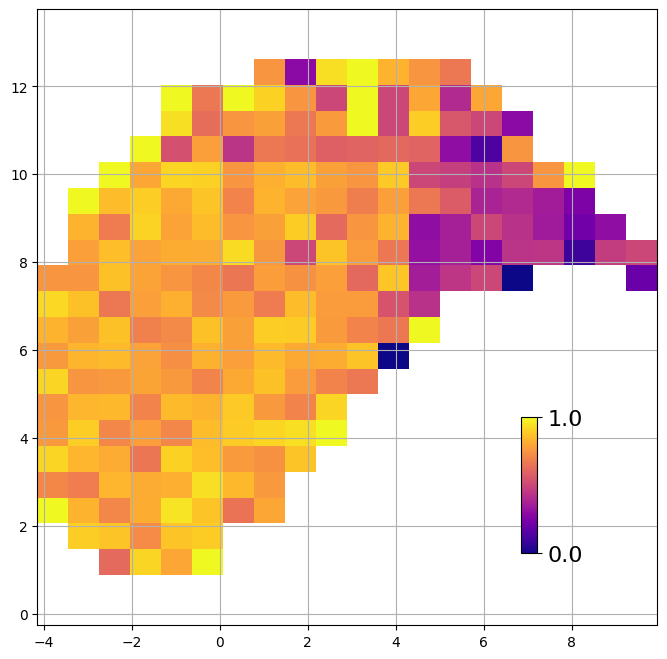

In [2]:
# Ripple heatmap — PLOT ONLY
fig, ax = plt.subplots(figsize=(8, 8))
ax.grid(True)
ax.axis("equal")
ax.set_facecolor("white")

masked_data = np.ma.masked_invalid(ripple_grid.T)

c2 = ax.imshow(
    masked_data,
    origin="lower",
    cmap=plasma,
    extent=[min_vals[0], max_vals[0], min_vals[1], max_vals[1]],
)

c2.set_clim(ripple_vmin, ripple_vmax)

cax = fig.add_axes([0.73, 0.20, 0.02, 0.17])
cbar = plt.colorbar(c2, cax=cax, orientation="vertical")
cbar.ax.tick_params(labelsize=16)
cbar.set_ticks([ripple_vmin, ripple_vmax])
cbar.set_ticklabels([f"{ripple_vmin:.1f}", f"{ripple_vmax}"])

plt.show()


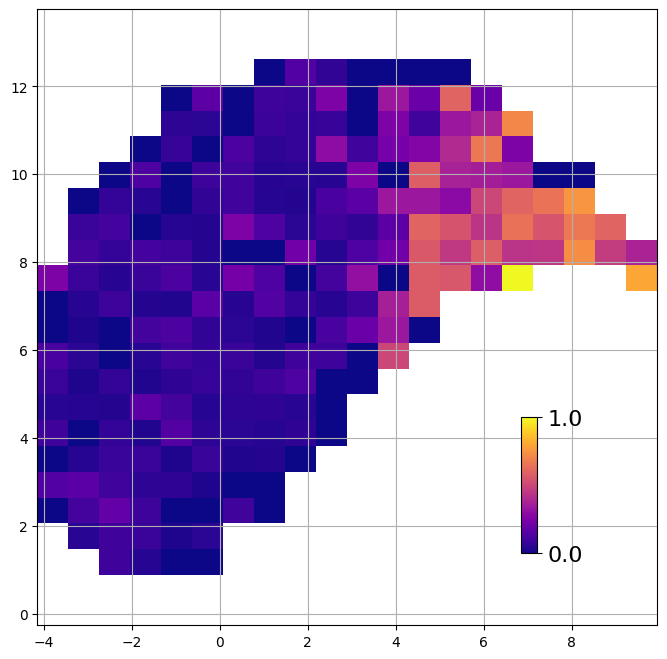

In [3]:
# IED heatmap — PLOT ONLY
fig, ax = plt.subplots(figsize=(8, 8))
ax.grid(True)
ax.axis("equal")
ax.set_facecolor("white")

masked_data = np.ma.masked_invalid(ied_grid.T)

c2 = ax.imshow(
    masked_data,
    origin="lower",
    cmap=plasma,
    extent=[min_vals[0], max_vals[0], min_vals[1], max_vals[1]],
)

c2.set_clim(ied_vmin, ied_vmax)

cax = fig.add_axes([0.73, 0.20, 0.02, 0.17])
cbar = plt.colorbar(c2, cax=cax, orientation="vertical")
cbar.ax.tick_params(labelsize=16)
cbar.set_ticks([ied_vmin, ied_vmax])
cbar.set_ticklabels([f"{ied_vmin:.1f}", f"{ied_vmax}"])

plt.show()


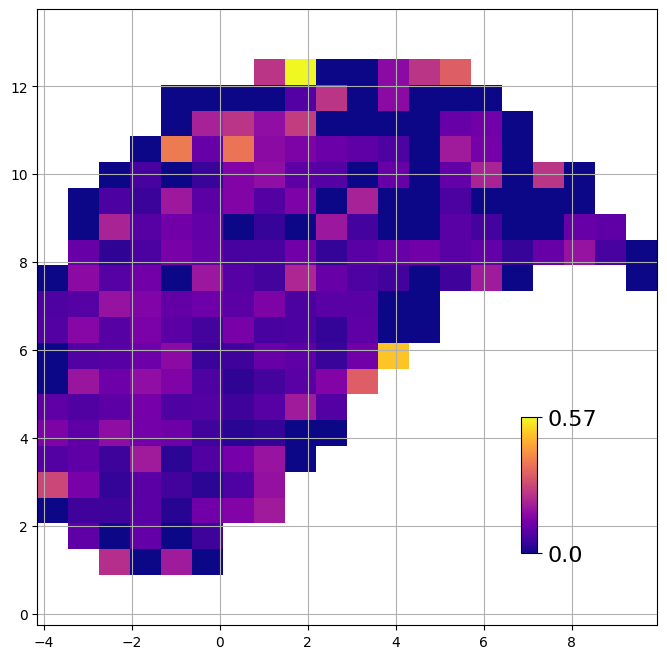

In [4]:
# Neither heatmap — PLOT ONLY
fig, ax = plt.subplots(figsize=(8, 8))
ax.grid(True)
ax.axis("equal")
ax.set_facecolor("white")

masked_data = np.ma.masked_invalid(neither_grid.T)

c2 = ax.imshow(
    masked_data,
    origin="lower",
    cmap=plasma,
    extent=[min_vals[0], max_vals[0], min_vals[1], max_vals[1]],
)

c2.set_clim(neither_vmin, neither_vmax)

cax = fig.add_axes([0.73, 0.20, 0.02, 0.17])
cbar = plt.colorbar(c2, cax=cax, orientation="vertical")
cbar.ax.tick_params(labelsize=16)
cbar.set_ticks([neither_vmin, neither_vmax])
cbar.set_ticklabels([f"{neither_vmin:.1f}", f"{neither_vmax:.2f}"])

plt.show()
